# Parallel Node Execution
## Review
In module 3, we went in-depth on `human-in-the-loop`, showing 3 common use cases:
1. `Approval` - We can interrupt our agent, surface state to a user, and allow the user to accept an action.
2. `Debugging` - We can rewind the graph to reproduce or avoid issues.
3. `Editing` - You can modify the state.

## Goals
This module will build on `human-in-the-loop` as well as the `memory` concepts discussed in module 2.

We will dive into `multi-agent` workflows and build up to a multi-agent research assistant that ties together all of the modules from this course.

To build this multi-agent research assistant, we'll first discuss a few LangGraph controllability topics. We'll start with parallelization.

## Fan out and Fan in
Let's build a simple linear graph that over-writes the state at each step.

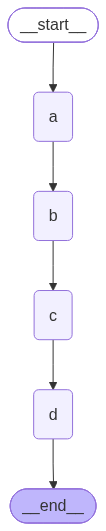

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm B"]
Adding I'm D to ["I'm C"]


{'state': ["I'm D"]}

In [15]:
# Import libraries
import os, getpass
from IPython.display import Image, display
from typing import Any, List
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    state: List[str]

class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding {self._value} to {state["state"]}")
        return {"state": [self._value]}

# Build graph
builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Logic
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("b", "c")
builder.add_edge("c", "d")
builder.add_edge("d", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

graph.invoke({"state": []})

Now, let's run `b` and `c` in parallel. And then run `d`. We can do this easily with fan-out from `a` to `b` and `c`, and then fan-in to `d`.

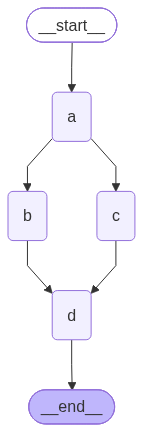

In [16]:
# Build the graph
builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Logic
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

We will see an error. This is because both `b` and `c` are writing to the same state key/channel in the same step.

In [17]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"state": []})
except InvalidUpdateError as e:
    print(f"An error occurred: {e}")

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
An error occurred: At key 'state': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE


When using fan out, we need to be sure that we are using a reducer if steps are writing to the same key/channel.

As we touched in Module 2, `operator.add` is a function from Python's built-in operator module.
When `operator.add` is applied to lists, it performs list concatenation.

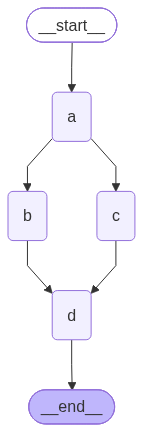

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm D to ["I'm A", "I'm B", "I'm C"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm D"]}

In [18]:
import operator
from typing import Annotated

class State(TypedDict):
    # The operator.add reducer makes it append-only
    state: Annotated[list, operator.add]

# Build the graph
builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Logic
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "d")
builder.add_edge("c", "d")
builder.add_edge("d", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({"state": []})

## Waiting for Nodes to Finish
Now, let's consider a case where one parallel path has more steps than the other one.

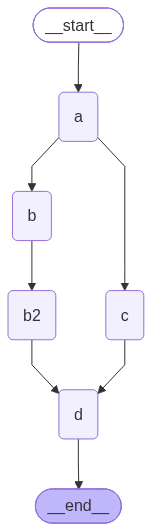

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm C", "I'm B2"]


{'state': ["I'm A", "I'm B", "I'm C", "I'm B2", "I'm D"]}

In [19]:
# Build the graph
builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Logic
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2","c"], "d")
builder.add_edge("d", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({"state": []})

## Setting the Order of State Updates
However, within each step we don't have specific control over the order of the state updates.

In simple terms, it is a deterministic order determined by LangGraph based on graph topology that we do not control.

Above, we see that `c` is added before `b2`. However, we can use a custom reducer to customize this e.g., sort state updates.

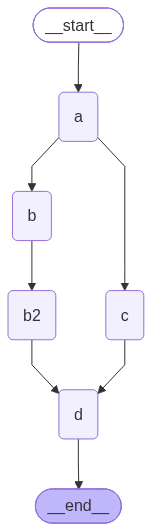

Adding I'm A to []
Adding I'm B to ["I'm A"]
Adding I'm C to ["I'm A"]
Adding I'm B2 to ["I'm A", "I'm B", "I'm C"]
Adding I'm D to ["I'm A", "I'm B", "I'm B2", "I'm C"]


{'state': ["I'm A", "I'm B", "I'm B2", "I'm C", "I'm D"]}

In [20]:
def sorting_reducer(left, right):
    """
    Combines and sorts the values in a list.
    """
    if not isinstance(left, list):
        left = [left]
    if not isinstance(right, list):
        right = [right]
    return sorted(left + right, reverse=False)

class State(TypedDict):
    state: Annotated[list, sorting_reducer]

# Build the graph
builder = StateGraph(State)
builder.add_node("a", ReturnNodeValue("I'm A"))
builder.add_node("b", ReturnNodeValue("I'm B"))
builder.add_node("b2", ReturnNodeValue("I'm B2"))
builder.add_node("c", ReturnNodeValue("I'm C"))
builder.add_node("d", ReturnNodeValue("I'm D"))

# Logic
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "b2")
builder.add_edge(["b2","c"], "d")
builder.add_edge("d", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({"state": []})

## Working with LLMs
Now, let's add a realistic example.

We want to gather context from two external sources (Wikipedia and Websearch) and have an LLM answer a question.

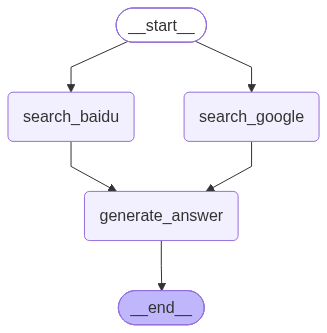

Based on the provided context, Nvidia's Q1 fiscal 2026 earnings results show conflicting information between sources:

- **Nvidia's official press release** states fiscal Q1 2026 revenue of **$44.1 billion** (up 12% from Q4 and up 69% year-over-year), with Data Center revenue of $39.1 billion (up 10% sequentially and 73% year-over-year). No earnings per share (EPS) figure is included in that snippet.
- **Yahoo Finance** reports earnings per share of **$1.87** and revenue of **$81.62 billion**, beating analyst expectations ($1.77 EPS and $79.18 billion revenue). This revenue figure is nearly double the official number, suggesting it may be an error or refer to a different period (e.g., full-year or a mislabeled quarter).
- **S&P Global** provides only preview estimates before earnings, not actual results, indicating expected revenue of around $43.2 billion for fiscal Q1 2026, which aligns more closely with the official release.

Given the discrepancy, the most reliable figure from the c

In [21]:
import os, getpass
import re 
from dotenv import load_dotenv
from urllib.parse import quote, urlencode
from bs4 import BeautifulSoup
from serpapi import GoogleSearch
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.document_loaders import WikipediaLoader, WebBaseLoader

# Load env variable for API Key
load_dotenv()
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL")
SERP_API_KEY = os.getenv("SERP_API_KEY")

# Set the Chat Model
llm = ChatOpenAI(
    model="deepseek-v4-pro",  # Or "deepseek-v4-flash" for a faster option
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    temperature=0
)

class State(TypedDict):
    question: str
    answer: str
    context: Annotated[list, operator.add]

def search_web(state):
    """
    Retrieve docs from web search.
    """
    params = {
        "q": state["question"],
        "location": "China",
        "hl": "en",
        "gl": "cn",
        "api_key": SERP_API_KEY
    }

    # Create the search object and execute it
    search = GoogleSearch(params)
    results = search.get_dict()

    # Handle case where no results are found
    if "organic_results" not in results:
        return {"context": ["No web results found."]}

    formatted_search_docs = "\n\n---\n\n".join([
        f"<Document href='{doc["link"]}'>\n{doc["snippet"]}\n</Document>"
        for doc in results["organic_results"][:3]
    ])

    return {"context": [formatted_search_docs]}

def search_baidu(state):
    """
    Retrieve docs from Baidu.
    """
    encoded_query = quote(state["question"])
    search_url = f"https://www.baide.com/s?wd={encoded_query}&rn=3"
    loader = WebBaseLoader(
        web_path=search_url,
        header_template={
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
            "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
            "Accept-Language": "en-US,en;q=0.9,en;q=0.8",
            "Accept-Encoding": "gzip, deflate, br",
            "Connection": "keep-alive",
            "Upgrade-Insecure-Requests": "1"
        }
    )
    docs = loader.load()
    html_content = docs[0].page_content
    soup = BeautifulSoup(html_content, "html.parser")
    results = []
    result_divs = soup.select('.result, .c-container, .c-row')
    for div in result_divs:
        link_elem = div.find('a', href=True)
        if not link_elem:
            continue
        link = link_elem.get('href', '')
        
        snippet_elem = div.find('div', class_=re.compile(r'c-abstract|c-span|content|summary'))
        if not snippet_elem:
            snippet_elem = div.find('p', class_=re.compile(r'c-abstract|c-span|content|summary'))
        snippet = snippet_elem.get_text(strip=True) if snippet_elem else ''
    
        if link:
            results.append({
                "link": link,
                "snippet": snippet
            })
    
    formatted_search_docs = "\n\n---\n\n".join([
        f"<Document href='{doc["link"]}'>\n{doc["snippet"]}\n</Document>"
        for doc in results
    ])
    return {"context": [formatted_search_docs]}

def search_wikipedia(state):
    """
    Retrieve docs from wikipedia.
    """
    search_docs = WikipediaLoader(query=state["question"], load_max_docs=2).load()
    formatted_search_docs = "\n\n---\n\n".join([
        f"<Document source='{doc.metadata["source"]}' page='{doc.metadata.get("page", "")}'>\n{doc.page_content}\n</Document>"
        for doc in search_docs
    ])
    return {"context": [formatted_search_docs]}

def generate_answer(state):
    """
    Node to answer a question.
    """
    context = state["context"]
    question = state["question"]

    answer_template = """
        Answer the question {question} using this context: {context}
    """
    answer_instructions = answer_template.format(question=question, context=context)
    answer = llm.invoke([SystemMessage(content=answer_instructions)] + [HumanMessage(content=f"Answer the question.")])
    return {"answer": answer}

# Build the graph
builder = StateGraph(State)
builder.add_node("search_google", search_web)
builder.add_node("search_baidu", search_baidu)
builder.add_node("generate_answer", generate_answer)

# Logic
builder.add_edge(START, "search_baidu")
builder.add_edge(START, "search_google")
builder.add_edge("search_baidu", "generate_answer")
builder.add_edge("search_google", "generate_answer")
builder.add_edge("generate_answer", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

result = graph.invoke({"question": "How were Nvidia's Q1 2026 earnings?"})
print(result["answer"].content)